In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# EDA: Exploratory Data Analysis

**Order for making machine learning model**

1. Load data
       ↓
2. Understand shape
       ↓
3. Understand columns & data types
       ↓
4. Check missing values
       ↓
5. Check duplicates
       ↓
6. Statistical summary
       ↓
7. Analyze target variable
       ↓
8. Univariate analysis
       ↓
9. Bivariate analysis
       ↓
10. Multivariate analysis
       ↓
11. Outlier analysis
       ↓
12. Feature engineering
       ↓
13. Re-analyze engineered features
       ↓
14. Decide how to handle missing values
       ↓
15. Decide which features to keep/drop
       ↓
16. Prepare data for ML
       ↓
17. Train model

**Your EDA should eventually answer these questions**

By the end of our Titanic EDA, we should be able to answer questions like:

Dataset structure <br>
How many rows and columns? <br>
What does each column represent? <br>
Which columns are numerical? <br>
Which are categorical? <br>
Which columns contain missing values? <br>
Are there duplicates? <br>
Target <br>
How many survived? <br>
How many died? <br>
What percentage survived? <br>
Is the target balanced? <br>
Passenger characteristics <br>
What is the age distribution? <br>
What is the fare distribution? <br>
How many males/females? <br>
How many passengers in each class? <br>
Which ports did passengers embark from? <br>
Relationships with survival <br>
Does Sex affect survival? <br>
Does Pclass affect survival? <br>
Does Age appear related to survival? <br>
Does Fare appear related to survival? <br>
Does Embarked appear related to survival? <br>
Does family size appear related to survival? <br>
Does traveling alone appear related to survival? <br>
Data quality <br>
Where are the missing values? <br>
Are there outliers? <br>
Are there suspicious values? <br>
Are there duplicate records? <br>
Feature engineering <br>
Can Name give us Title? <br>
Can SibSp and Parch give us FamilySize? <br>
Can we determine whether someone traveled alone? <br>
Can Cabin tell us whether a cabin was recorded? <br>
Is Ticket useful for identifying groups? <br>

In [7]:
df = pd.read_csv('Titanic-Dataset.csv')

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
410,411,0,3,"Sdycoff, Mr. Todor",male,NaN,0,0,349222,7.8958,NaN,S
831,832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,NaN,S
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.00,0,0,2667,7.2250,NaN,C
632,633,1,1,"Stahelin-Maeglin, Dr. Max",male,32.00,0,0,13214,30.5000,B50,C
134,135,0,2,"Sobey, Mr. Samuel James Hayden",male,25.00,0,0,C.A. 29178,13.0000,NaN,S


In [7]:
df.shape

(891, 12)

In [9]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 891
Columns: 12


In [10]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [13]:
df.select_dtypes(include=np.number).columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [14]:
df.select_dtypes(include="object").columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [15]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df[df.duplicated()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [18]:
df["PassengerId"].duplicated().sum()

np.int64(0)

In [19]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [21]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

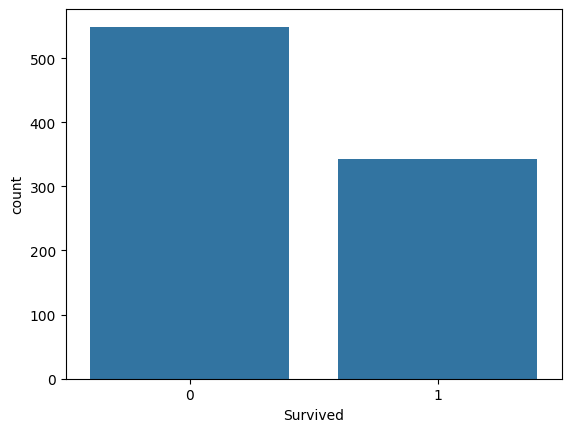

In [22]:
sns.countplot(data=df, x="Survived")
plt.show()

In [23]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Sex', ylabel='count'>

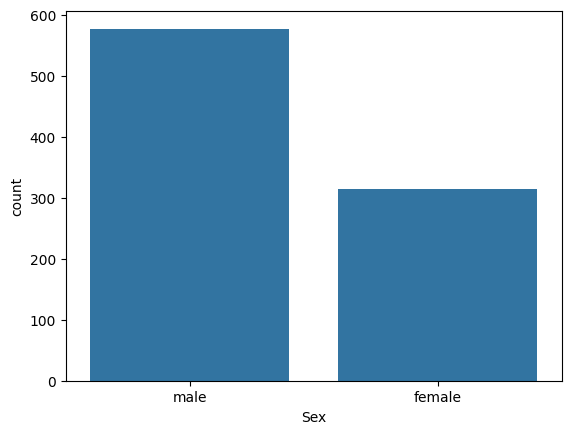

In [24]:
sns.countplot(data=df, x='Sex')

In [25]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<Axes: xlabel='Pclass', ylabel='count'>

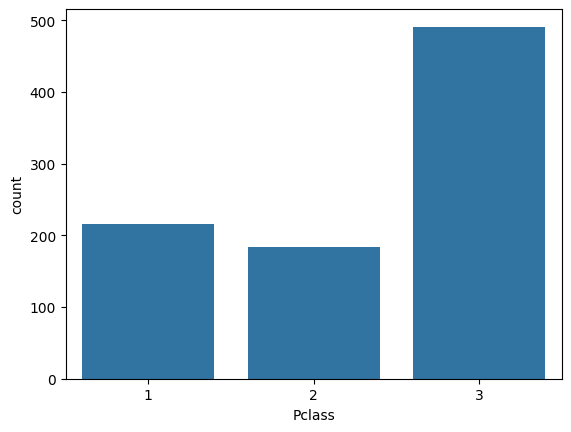

In [26]:
sns.countplot(data=df, x='Pclass')

<Axes: xlabel='Embarked', ylabel='count'>

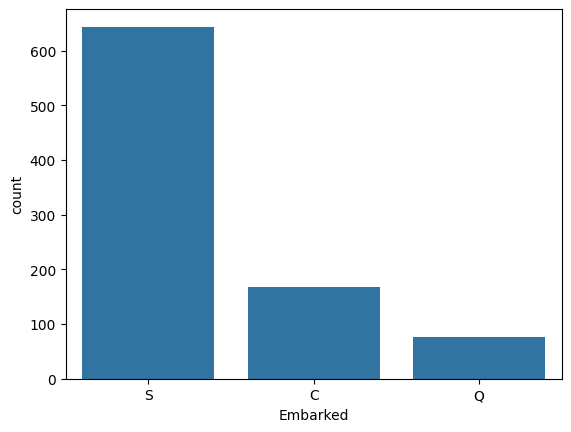

In [27]:
sns.countplot(data=df, x='Embarked')

<Axes: xlabel='Age', ylabel='count'>

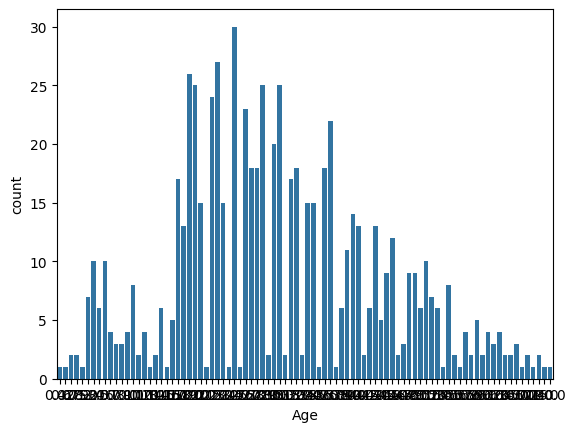

In [30]:
sns.countplot(data=df, x='Age')

<Axes: xlabel='Age', ylabel='Count'>

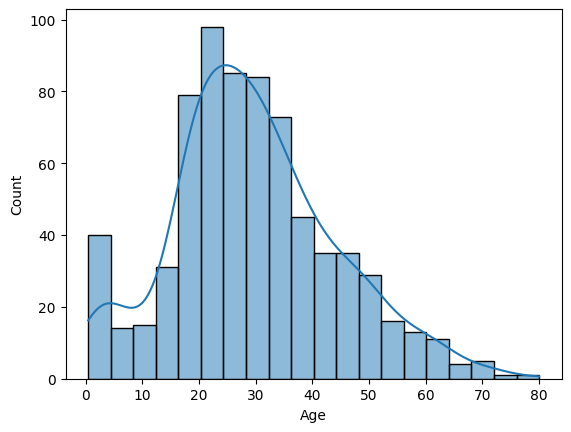

In [31]:
sns.histplot(data=df, x='Age', kde=True)

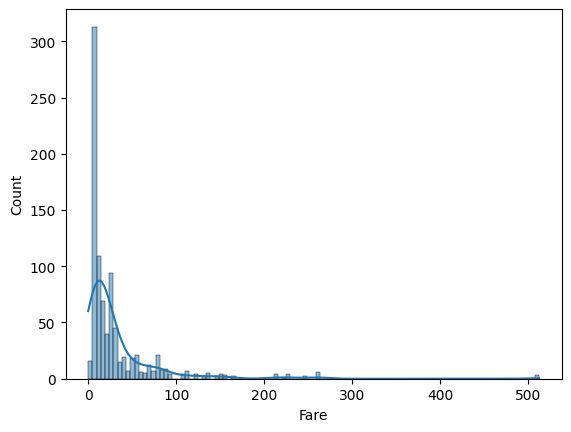

In [32]:
sns.histplot(data=df, x="Fare", kde=True)
plt.show()

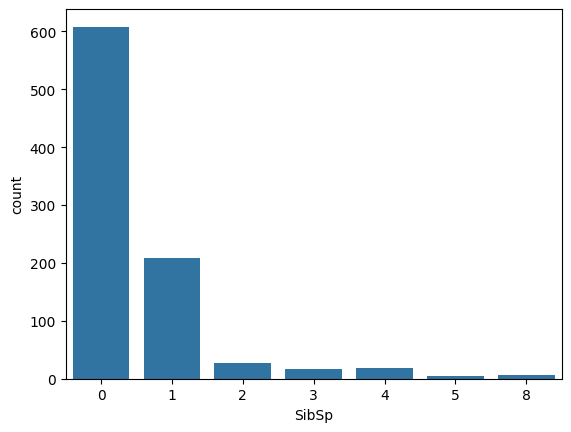

In [33]:
sns.countplot(data=df, x="SibSp")
plt.show()

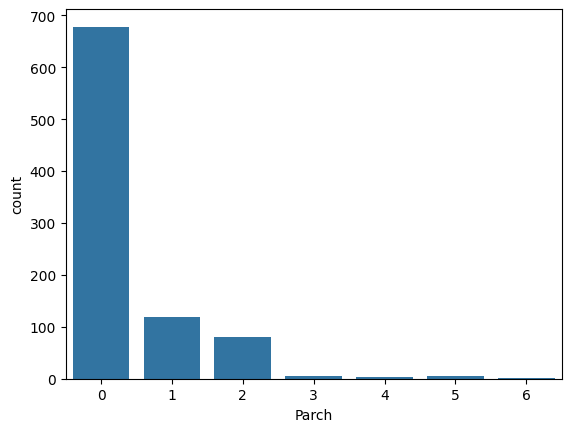

In [35]:
sns.countplot(data=df, x="Parch")
plt.show()

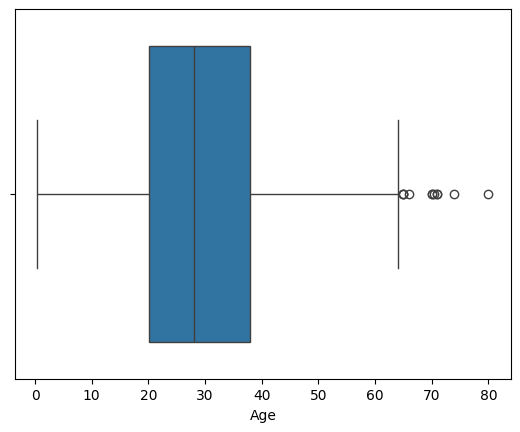

In [36]:
sns.boxplot(data=df, x="Age")
plt.show()

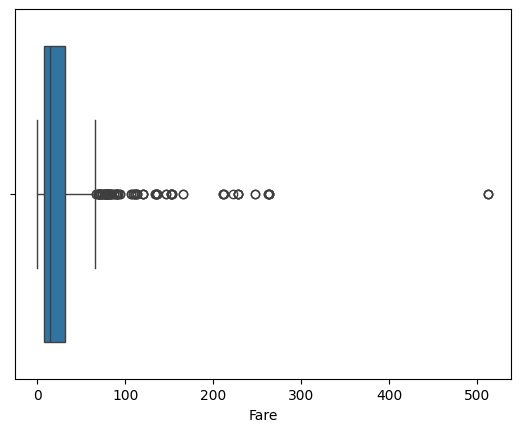

In [37]:
sns.boxplot(data=df, x="Fare")
plt.show()

In [38]:
df[df["Fare"] > df["Fare"].quantile(0.95)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.00,3,2,19950,263.0000,C23 C25 C27,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.00,3,2,19950,263.0000,C23 C25 C27,S
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.00,0,1,PC 17558,247.5208,B58 B60,C
195,196,1,1,"Lurette, Miss. Elise",female,58.00,0,0,PC 17569,146.5208,B80,C
215,216,1,1,"Newell, Miss. Madeleine",female,31.00,1,0,35273,113.2750,D36,C
258,259,1,1,"Ward, Miss. Anna",female,35.00,0,0,PC 17755,512.3292,NaN,C
268,269,1,1,"Graham, Mrs. William Thompson (Edith Junkins)",female,58.00,0,1,PC 17582,153.4625,C125,S
269,270,1,1,"Bissette, Miss. Amelia",female,35.00,0,0,PC 17760,135.6333,C99,S
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S


In [39]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [40]:
pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
) * 100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


<Axes: xlabel='Sex', ylabel='count'>

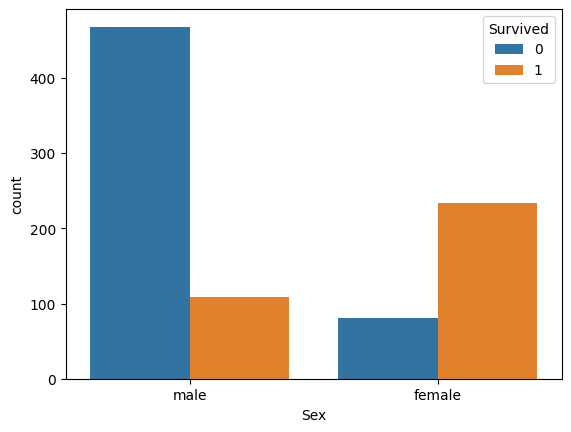

In [43]:
sns.countplot(data=df, x="Sex", hue='Survived')

In [44]:
pd.crosstab(df["Pclass"], df["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


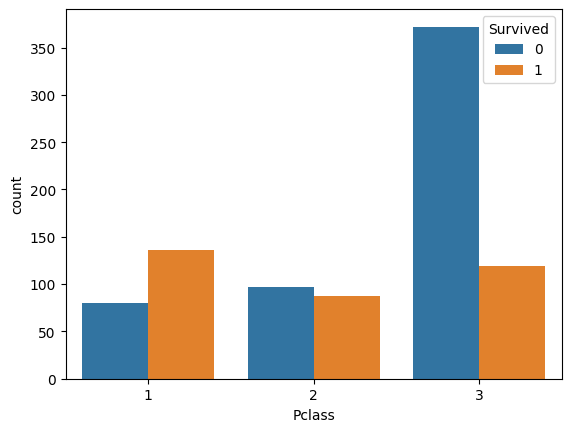

In [45]:
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.show()

<Axes: xlabel='Embarked', ylabel='count'>

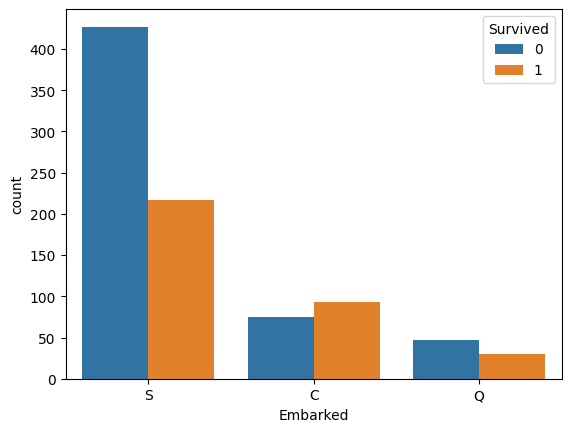

In [5]:
sns.countplot(data=df, x='Embarked', hue='Survived')

<Axes: xlabel='Survived', ylabel='Age'>

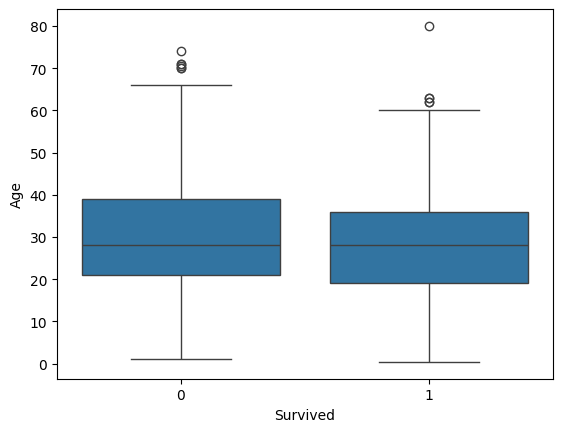

In [6]:
sns.boxplot(data=df, x='Survived', y='Age')

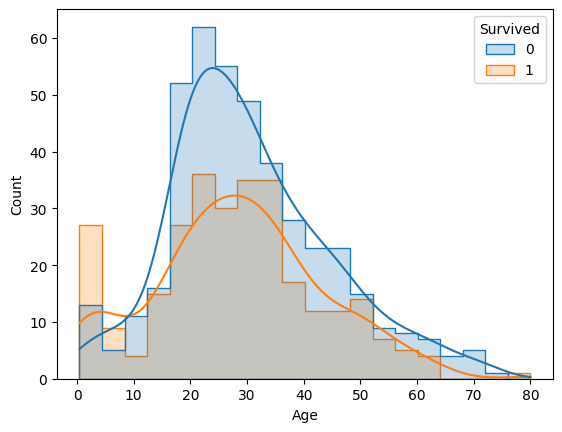

In [7]:
sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    kde=True,
    element="step"
)
plt.show()

<Axes: xlabel='Survived', ylabel='Fare'>

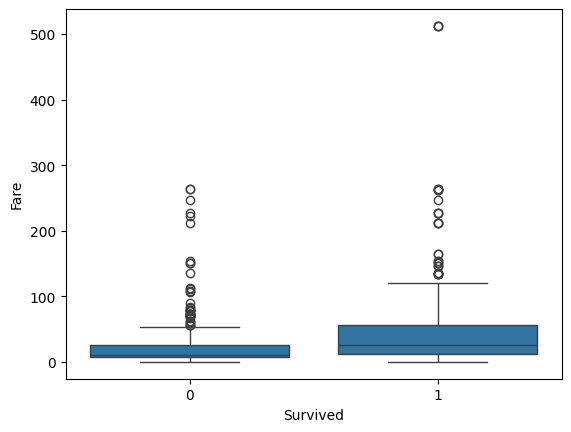

In [8]:
sns.boxplot(data=df, x='Survived', y='Fare')

In [9]:
corr = df.select_dtypes(include=np.number).corr()

corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


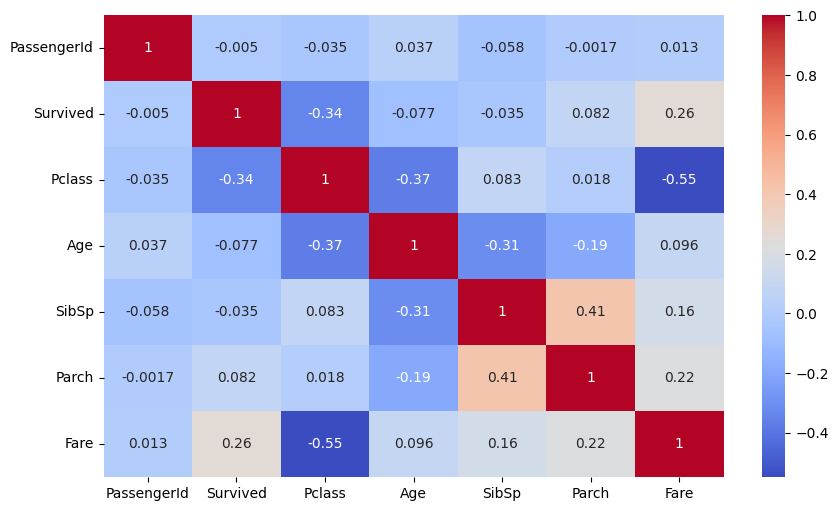

In [10]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

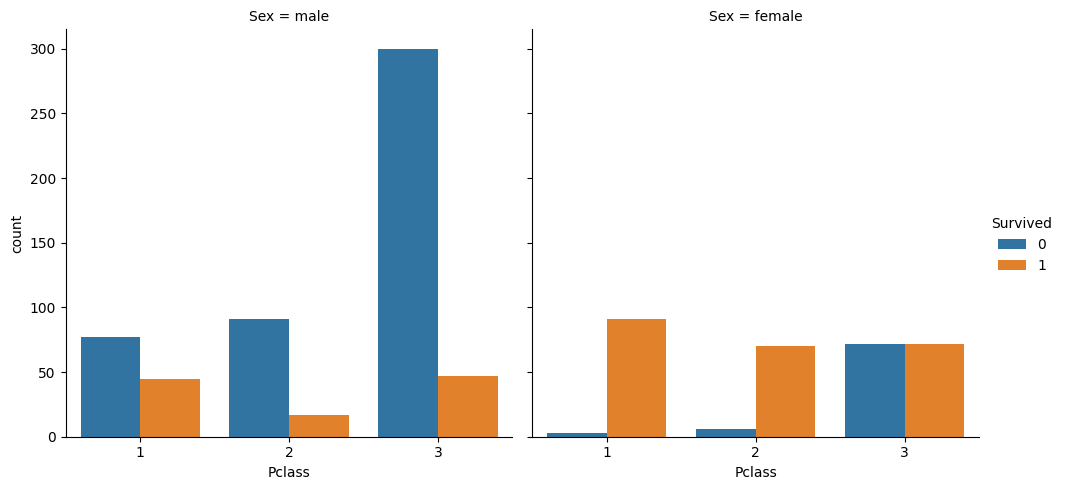

In [11]:
sns.catplot(
    data=df,
    x="Pclass",
    hue="Survived",
    col="Sex",
    kind="count"
)

plt.show()

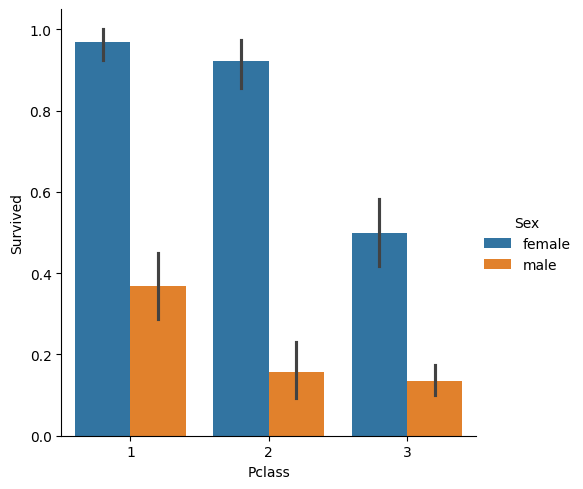

In [12]:
sns.catplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex",
    kind="bar"
)

plt.show()

In [14]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [15]:
df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


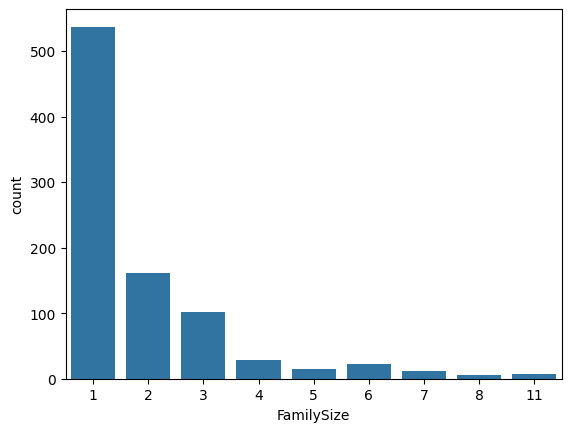

In [16]:
sns.countplot(data=df, x="FamilySize")
plt.show()

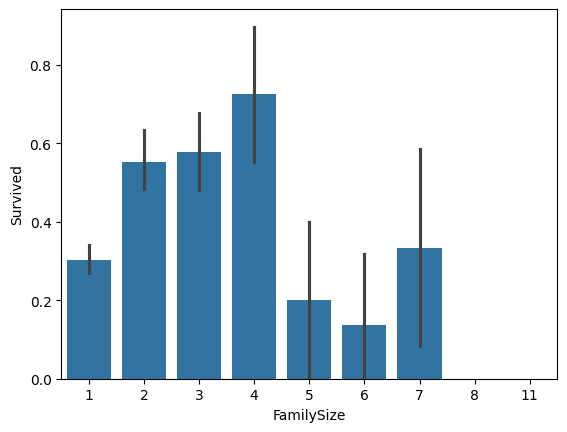

In [17]:
sns.barplot(
    data=df,
    x="FamilySize",
    y="Survived"
)

plt.show()

Solo Traveler

In [20]:
df["Alone"] = (df["FamilySize"] == 1).astype(int)

In [19]:
df["Alone"].value_counts()

Alone
1    537
0    354
Name: count, dtype: int64

In [21]:
pd.crosstab(
    df["Alone"],
    df["Survived"],
    normalize="index"
) * 100

Survived,0,1
Alone,,
0,49.435028,50.564972
1,69.646182,30.353818


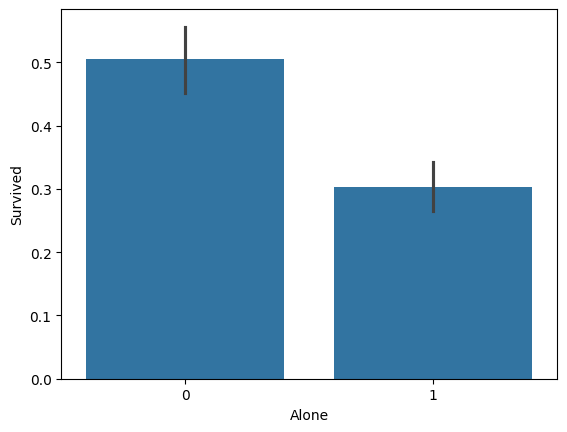

In [22]:
sns.barplot(
    data=df,
    x="Alone",
    y="Survived"
)

plt.show()

In [ ]:
Extracting Name Title

In [23]:
df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.")

In [24]:
df["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [25]:
df["Cabin"].isnull().sum()

np.int64(687)

In [26]:
df["HasCabin"] = df["Cabin"].notnull().astype(int)

In [27]:
pd.crosstab(
    df["HasCabin"],
    df["Survived"],
    normalize="index"
) * 100

Survived,0,1
HasCabin,,
0,70.014556,29.985444
1,33.333333,66.666667


In [28]:
df["Ticket"].nunique()

681

In [29]:
len(df)

891

In [30]:
df["Ticket"].value_counts().head(10)

Ticket
347082          7
1601            7
CA. 2343        7
3101295         6
CA 2144         6
347088          6
382652          5
S.O.C. 14879    5
113760          4
19950           4
Name: count, dtype: int64

In [31]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [32]:
df.groupby("Survived")[["Age", "Fare", "SibSp", "Parch"]].mean()

,Age,Fare,SibSp,Parch
Survived,,,,
0,30.626179,22.117887,0.553734,0.329690
1,28.343690,48.395408,0.473684,0.464912


In [33]:
df["Age"].min(), df["Age"].max()

(0.42, 80.0)

In [34]:
df["Fare"].min(), df["Fare"].max()

(0.0, 512.3292)

In [35]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

summary

,Data Type,Missing Values,Unique Values
PassengerId,int64,0,891
Survived,int64,0,2
Pclass,int64,0,3
Name,object,0,891
Sex,object,0,2
Age,float64,177,88
SibSp,int64,0,7
Parch,int64,0,7
Ticket,object,0,681
Fare,float64,0,248


# Data Preprocessing

In [8]:
df_clean = df.copy()

In [9]:
df_clean.shape

(891, 12)

In [10]:
X = df_clean.drop("Survived", axis=1)
y = df_clean["Survived"]

In [11]:
X.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [13]:
X.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [14]:
X = X.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

In [15]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


****Extracting Title from name****

In [16]:
df_clean["Title"] = df_clean["Name"].str.extract(r",\s*([^.]*)\.")

In [17]:
df_clean[["Name", "Title"]].head()

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


In [18]:
df_clean["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

****Grouping rare title****

In [19]:
title_counts = df_clean["Title"].value_counts()

rare_titles = title_counts[title_counts < 10].index

df_clean["Title"] = df_clean["Title"].replace(rare_titles, "Rare")

In [20]:
df_clean["Title"].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

**Family Size**

In [21]:
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1

In [22]:
df_clean[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


**Is Alone**

In [23]:
df_clean["IsAlone"] = (df_clean["FamilySize"] == 1).astype(int)

In [24]:
df_clean[["FamilySize", "IsAlone"]].head(10)

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


In [25]:
df_clean["HasCabin"] = df_clean["Cabin"].notna().astype(int)

In [26]:
df_clean[["Cabin", "HasCabin"]].head(10)

,Cabin,HasCabin
0,NaN,0
1,C85,1
2,NaN,0
3,C123,1
4,NaN,0
5,NaN,0
6,E46,1
7,NaN,0
8,NaN,0
9,NaN,0


In [27]:
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,0


**New Feature**

In [28]:
X = df_clean.drop("Survived", axis=1)
y = df_clean["Survived"]

In [29]:
X.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'FamilySize', 'IsAlone',
       'HasCabin'],
      dtype='object')

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
X_train.shape
X_test.shape

(179, 15)

In [32]:
X_train.dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
Title           object
FamilySize       int64
IsAlone          int64
HasCabin         int64
dtype: object

In [33]:
numeric_features = [
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "FamilySize",
    "IsAlone",
    "HasCabin"
]

In [34]:
categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title"
]

**Handle missing values**

In [35]:
X_train[numeric_features].isnull().sum()

Age           137
Fare            0
SibSp           0
Parch           0
FamilySize      0
IsAlone         0
HasCabin        0
dtype: int64

In [36]:
from sklearn.impute import SimpleImputer

numeric_imputer = SimpleImputer(strategy="median")

In [37]:
X_train[categorical_features].isnull().sum()

Pclass      0
Sex         0
Embarked    2
Title       0
dtype: int64

In [38]:
categorical_imputer = SimpleImputer(strategy="most_frequent")

# One hot encoding
Male female -> 0 1
Embarked ->  S Q C


In [39]:
categorical_columns = ["Sex", "Embarked", "Title", "Pclass"]

df_clean[categorical_columns].head()

,Sex,Embarked,Title,Pclass
0,male,S,Mr,3
1,female,C,Mrs,1
2,female,S,Miss,3
3,female,S,Mrs,1
4,male,S,Mr,3


In [40]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

In [41]:
sex_encoded = encoder.fit_transform(
    df_clean[["Sex"]]
)

In [42]:
df_clean["Sex"].shape
df_clean[["Sex"]].shape

(891, 1)

In [43]:
sex_encoded.toarray()

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [0., 1.],
       [0., 1.]])

In [44]:
categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title"
]

In [45]:
encode_data = encoder.fit_transform(
    df_clean[categorical_features]
)

In [46]:
encoder.get_feature_names_out()

array(['Pclass_1', 'Pclass_2', 'Pclass_3', 'Sex_female', 'Sex_male',
       'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Embarked_nan',
       'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs',
       'Title_Rare'], dtype=object)

In [49]:
encoded_data = encoder.fit_transform()

TypeError: TransformerMixin.fit_transform() missing 1 required positional argument: 'X'

In [50]:
OneHotEncoder(handle_unknown="ignore")

OneHotEncoder(handle_unknown='ignore')

In [51]:
encoder.fit(X_train)

OneHotEncoder()

In [52]:
encoder.fit(X_train[categorical_features])

X_train_encoded = encoder.transform(
    X_train[categorical_features]
)

X_test_encoded = encoder.transform(
    X_test[categorical_features]
)

In [53]:
from sklearn.preprocessing import StandardScaler

In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [55]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [56]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [57]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

                X
                │
       ┌─────────┴─────────┐
       ↓                   ↓
 Numerical             Categorical
       ↓                   ↓
 Impute median       Impute mode
       ↓                   ↓
    Scale             One-hot encode
       └─────────┬─────────┘
                ↓
        Final feature matrix
        

In [58]:
X_train_processed = preprocessor.fit_transform(X_train)

In [59]:
X_test_processed = preprocessor.transform(X_test)

In [60]:
fit_transform(X_train)

NameError: name 'fit_transform' is not defined

In [61]:
transform()

NameError: name 'transform' is not defined

In [64]:
X_train_processed.shape

(712, 20)

In [65]:
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,HasCabin
692,693,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S,Mr,1,1,0
481,482,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0000,NaN,S,Mr,1,1,0
527,528,1,"Farthing, Mr. John",male,NaN,0,0,PC 17483,221.7792,C95,S,Mr,1,1,1
855,856,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S,Mrs,2,0,0
801,802,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,NaN,S,Mrs,3,0,0


In [66]:
X = X.drop(
    ["PassengerId", "Name", "Ticket", "Cabin"],
    axis=1
)

In [67]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,HasCabin
0,3,male,22.0,1,0,7.2500,S,Mr,2,0,0
1,1,female,38.0,1,0,71.2833,C,Mrs,2,0,1
2,3,female,26.0,0,0,7.9250,S,Miss,1,1,0
3,1,female,35.0,1,0,53.1000,S,Mrs,2,0,1
4,3,male,35.0,0,0,8.0500,S,Mr,1,1,0


In [68]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [69]:
X.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title',
       'FamilySize', 'IsAlone', 'HasCabin'],
      dtype='object')

**Splitting the data into training and testing data**

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [71]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (712, 11)
X_test : (179, 11)
y_train: (712,)
y_test : (179,)


In [72]:
print("Training target:")
print(y_train.value_counts(normalize=True))

print("\nTesting target:")
print(y_test.value_counts(normalize=True))

Training target:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Testing target:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [73]:
X_train[numeric_features].dtypes

Age           float64
Fare          float64
SibSp           int64
Parch           int64
FamilySize      int64
IsAlone         int64
HasCabin        int64
dtype: object

In [74]:
X_train[categorical_features].dtypes

Pclass       int64
Sex         object
Embarked    object
Title       object
dtype: object

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [76]:
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [77]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

# Logistic Regression

In [78]:
from sklearn.linear_model import LogisticRegression

In [79]:
classifier = LogisticRegression(max_iter=1000)

In [80]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ]
)

In [81]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Parch', 'FamilySize',
                                                   'IsAlone', 'HasCabin']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [82]:
y_pred = model.predict(X_test)

In [83]:
y_pred[:20]

array([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1])

In [84]:
y_prob = model.predict_proba(X_test)[:, 1]

In [85]:
y_prob[:20]

array([0.04941313, 0.04790802, 0.1264734 , 0.02931763, 0.67158912,
       0.62797498, 0.70606845, 0.56513073, 0.33677967, 0.12944508,
       0.13708718, 0.06096643, 0.56495119, 0.1449928 , 0.2723256 ,
       0.15004552, 0.22890108, 0.07653792, 0.10464987, 0.71842011])

In [86]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8324022346368715


**Confussion Matrix**

In [87]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[97 13]
 [17 52]]


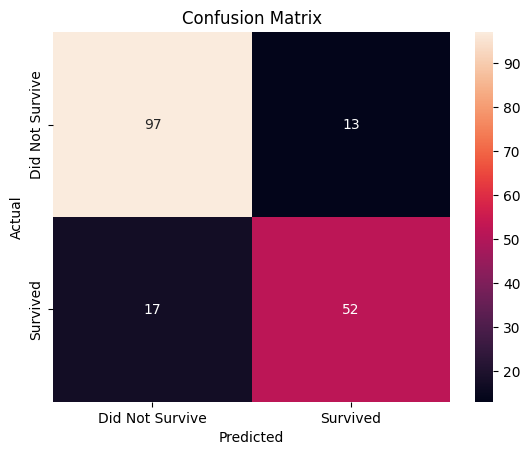

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [89]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87       110
           1       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [90]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
565,0,0
160,0,0
553,1,0
860,0,0
241,1,1
559,1,1
387,1,1
536,0,1
698,0,0
99,0,0


In [91]:
comparison[
    comparison["Actual"] != comparison["Predicted"]
]

,Actual,Predicted
553,1,0
536,0,1
712,1,0
455,1,0
65,1,0
297,0,1
40,0,1
564,0,1
502,0,1
17,1,0


In [92]:
analysis_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability": y_prob
})

analysis_df["Correct"] = (
    analysis_df["Actual"] ==
    analysis_df["Predicted"]
)

analysis_df.head()

,Actual,Predicted,Probability,Correct
0,0,0,0.049413,True
1,0,0,0.047908,True
2,1,0,0.126473,False
3,0,0,0.029318,True
4,1,1,0.671589,True


In [93]:
y_prob = model.predict_proba(X_test)[:, 1]

In [94]:
from sklearn.metrics import roc_curve

In [95]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

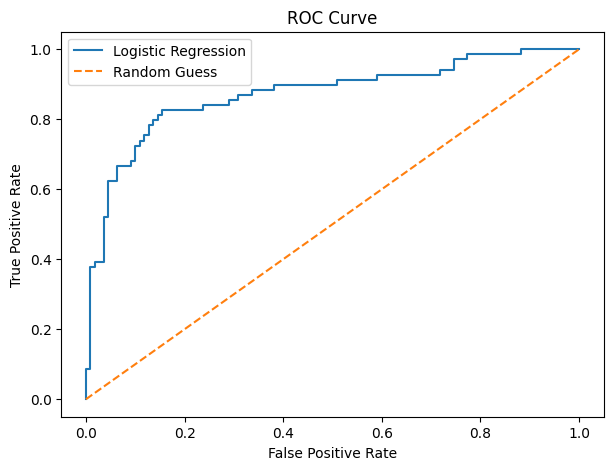

In [96]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [97]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.8715


In [98]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [99]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.8324
Accuracy: 83.24%


In [154]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")

Precision: 0.8000


In [153]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print(f"Recall: {recall:.4f}")

Recall: 0.7536


In [152]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.7761


# Decission Tree


In [100]:
from sklearn.tree import DecisionTreeClassifier

In [101]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

In [102]:
tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Parch', 'FamilySize',
                                                   'IsAlone', 'HasCabin']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [103]:
tree_pred = tree_model.predict(X_test)

In [104]:
tree_accuracy = accuracy_score(
    y_test,
    tree_pred
)

print(f"Decision Tree Accuracy: {tree_accuracy:.4f}")

Decision Tree Accuracy: 0.7877


# KNN

In [105]:
from sklearn.neighbors import KNeighborsClassifier

In [106]:
knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            KNeighborsClassifier(n_neighbors=5)
        )
    ]
)

In [107]:
n_neighbors=5

In [108]:
knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Parch', 'FamilySize',
                                                   'IsAlone', 'HasCabin']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title'])])),
                ('classifier', KNeighborsClassifier())])

In [109]:
knn_pred = knn_model.predict(X_test)

In [110]:
knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)

print(f"KNN Accuracy: {knn_accuracy:.4f}")

KNN Accuracy: 0.8045


In [111]:
print(classification_report(
    y_test,
    knn_pred
))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.76      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [112]:
knn_prob = knn_model.predict_proba(X_test)[:, 1]

knn_auc = roc_auc_score(
    y_test,
    knn_prob
)

print(f"KNN ROC-AUC: {knn_auc:.4f}")

KNN ROC-AUC: 0.8379


In [113]:
StandardScaler()

StandardScaler()

In [114]:
k_values = [3, 5, 7, 9, 11, 15, 20]


In [118]:
for k in k_values:

    knn = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                KNeighborsClassifier(
                    n_neighbors=k
                )
            )
        ]
    )

    scores = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    print(
        f"K={k}: "
        f"{scores.mean():.4f}"
    )

# Support Vector Machine

In [119]:
from sklearn.svm import SVC

In [120]:
svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            SVC(
                kernel="rbf",
                probability=True,
                random_state=42
            )
        )
    ]
)

In [121]:
svm_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Parch', 'FamilySize',
                                                   'IsAlone', 'HasCabin']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title'])])),
                ('classifier', SVC(probability=True, random_state=42))])

In [122]:
svm_pred = svm_model.predict(X_test)

In [123]:
svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

print(f"SVM Accuracy: {svm_accuracy:.4f}")

SVM Accuracy: 0.8436


In [124]:
print(classification_report(
    y_test,
    svm_pred
))

              precision    recall  f1-score   support

           0       0.86      0.89      0.88       110
           1       0.82      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



In [125]:
svm_prob = svm_model.predict_proba(X_test)[:, 1]

svm_auc = roc_auc_score(
    y_test,
    svm_prob
)

print(f"SVM ROC-AUC: {svm_auc:.4f}")

SVM ROC-AUC: 0.8440


# Random Forest

In [126]:
from sklearn.ensemble import RandomForestClassifier

In [127]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [128]:
n_estimators=200

In [129]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Parch', 'FamilySize',
                                                   'IsAlone', 'HasCabin']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [132]:
rf_pred = rf_model.predict(X_test)

In [133]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.8045


In [135]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.84      0.85      0.84       110
           1       0.75      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [136]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print(f"Random Forest ROC-AUC: {rf_auc:.4f}")

Random Forest ROC-AUC: 0.8262


# Naive Bayes

**GaussianNB**

In [137]:
from sklearn.naive_bayes import GaussianNB

In [138]:
OneHotEncoder(handle_unknown="ignore")

OneHotEncoder(handle_unknown='ignore')

In [139]:
OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [142]:
categorical_transformer_nb = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [143]:
preprocessor_nb = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer_nb,
            categorical_features
        )
    ]
)

In [144]:
nb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_nb),
        (
            "classifier",
            GaussianNB()
        )
    ]
)

In [145]:
nb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Parch', 'FamilySize',
                                                   'IsAlone', 'HasCabin']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title'])])),
                ('classifier', GaussianNB())])

In [146]:
nb_pred = nb_model.predict(X_test)

In [147]:
nb_accuracy = accuracy_score(
    y_test,
    nb_pred
)

print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")

Naive Bayes Accuracy: 0.8045


In [148]:
nb_prob = nb_model.predict_proba(X_test)[:, 1]

nb_auc = roc_auc_score(
    y_test,
    nb_prob
)

print(f"Naive Bayes ROC-AUC: {nb_auc:.4f}")

Naive Bayes ROC-AUC: 0.8490


In [150]:
models = {
    "Logistic Regression": model,
    "KNN": knn_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "Naive Bayes": nb_model
}

In [156]:
models = {
    "Logistic Regression": model,
    "KNN": knn_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "Naive Bayes": nb_model
}

In [157]:
comparison = []

for name, current_model in models.items():

    current_model.fit(
        X_train,
        y_train
    )

    pred = current_model.predict(
        X_test
    )

    prob = current_model.predict_proba(
        X_test
    )[:, 1]

    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            pred
        ),
        "Precision": precision_score(
            y_test,
            pred
        ),
        "Recall": recall_score(
            y_test,
            pred
        ),
        "F1": f1_score(
            y_test,
            pred
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            prob
        )
    })

In [159]:
comparison_df = pd.DataFrame(
    comparison
)

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.832402,0.800000,0.753623,0.776119,0.871542
1,KNN,0.804469,0.757576,0.724638,0.740741,0.837879
2,SVM,0.843575,0.815385,0.768116,0.791045,0.844005
3,Random Forest,0.804469,0.750000,0.739130,0.744526,0.826219
4,Naive Bayes,0.804469,0.729730,0.782609,0.755245,0.849012


In [160]:
from sklearn.model_selection import cross_validate

cv_comparison = []

for name, current_model in models.items():

    scores = cross_validate(
        current_model,
        X_train,
        y_train,
        cv=5,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ]
    )

    cv_comparison.append({
        "Model": name,
        "Accuracy": scores[
            "test_accuracy"
        ].mean(),

        "Precision": scores[
            "test_precision"
        ].mean(),

        "Recall": scores[
            "test_recall"
        ].mean(),

        "F1": scores[
            "test_f1"
        ].mean(),

        "ROC-AUC": scores[
            "test_roc_auc"
        ].mean()
    })

In [161]:
cv_comparison_df = pd.DataFrame(
    cv_comparison
)

cv_comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.828691,0.789968,0.754545,0.771388,0.868241
1,KNN,0.807673,0.773573,0.703569,0.735966,0.847425
2,SVM,0.818891,0.786546,0.725455,0.753484,0.850585
3,Random Forest,0.793687,0.738500,0.718249,0.728085,0.855038
4,Naive Bayes,0.802019,0.720515,0.794882,0.755423,0.851618


# Tuning Logistic Regression Model

**GridSearchCV will:**

* Try different parameter combinations.
* Perform cross-validation for each combination.
* Compare their scores.
* Select the best combination.

In [162]:
from sklearn.model_selection import GridSearchCV

In [163]:
logistic_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear", "lbfgs"]
}

In [164]:
logistic_grid = GridSearchCV(
    estimator=model,
    param_grid=logistic_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [165]:
logistic_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Fare',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'FamilySize',
                                                                          'IsAlone',
                                                                          'HasCabin']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Pclass',
                                                                          'Sex',
                                                                          'Embarked',
                                                                          'Title'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [166]:
print(logistic_grid.best_params_)

{'classifier__C': 1, 'classifier__solver': 'lbfgs'}


In [167]:
print(logistic_grid.best_score_)

0.8286910272825766


In [168]:
best_logistic = logistic_grid.best_estimator_

In [169]:
best_logistic

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Parch', 'FamilySize',
                                                   'IsAlone', 'HasCabin']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title'])])),
                ('classifier', LogisticRegression(C=1, max_iter=1000))])

In [170]:
logistic_pred = best_logistic.predict(X_test)

In [172]:
from sklearn.metrics import accuracy_score

logistic_test_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

print("Logistic Regression Test Accuracy:", logistic_test_accuracy)

Logistic Regression Test Accuracy: 0.8324022346368715


In [185]:
logistic_prob = best_logistic.predict_proba(X_test)[:, 1]

In [186]:
from sklearn.metrics import roc_auc_score

logistic_test_auc = roc_auc_score(
    y_test,
    logistic_prob
)

print("Logistic Regression Test ROC-AUC:", logistic_test_auc)

Logistic Regression Test ROC-AUC: 0.8715415019762845


# Tuning KNN Model

In [173]:
knn_param_grid = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "classifier__weights": ["uniform", "distance"],
    "classifier__p": [1, 2]
}

In [174]:
knn_grid = GridSearchCV(
    estimator=knn_model,
    param_grid=knn_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [175]:
knn_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Fare',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'FamilySize',
                                                                          'IsAlone',
                                                                          'HasCabin']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Pclass',
                                                                          'Sex',
                                                                          'Embarked',
                                                                          'Title'])])),
                                       ('classifier', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
                         'classifier__p': [1, 2],
                         'classifier__weights': ['uniform', 'distance']},
             scoring='accuracy')

In [176]:
print(knn_grid.best_params_)

{'classifier__n_neighbors': 3, 'classifier__p': 1, 'classifier__weights': 'uniform'}


In [177]:
print(knn_grid.best_score_)

0.8329360780065006


In [180]:
best_knn = knn_grid.best_estimator_

In [181]:
knn_pred = best_knn.predict(X_test)

In [182]:
knn_test_accuracy = accuracy_score(
    y_test,
    knn_pred
)

print("KNN Test Accuracy:", knn_test_accuracy)

KNN Test Accuracy: 0.8100558659217877


In [183]:
knn_prob = best_knn.predict_proba(X_test)[:, 1]

knn_test_auc = roc_auc_score(
    y_test,
    knn_prob
)

print("KNN Test ROC-AUC:", knn_test_auc)

KNN Test ROC-AUC: 0.8598155467720685


In [188]:
comparison = pd.DataFrame({
    "Model": [
        "Tuned Logistic Regression",
        "Tuned KNN"
    ],
    "CV Accuracy": [
        logistic_grid.best_score_,
        knn_grid.best_score_
    ],
    "Test Accuracy": [
        logistic_test_accuracy,
        knn_test_accuracy
    ],
    "Test ROC-AUC": [
        logistic_test_auc,
        knn_test_auc
    ]
})

comparison

,Model,CV Accuracy,Test Accuracy,Test ROC-AUC
0,Tuned Logistic Regression,0.828691,0.832402,0.871542
1,Tuned KNN,0.832936,0.810056,0.859816
